# WPL Data Analysis (2023-2025)

**Exploratory Data Analysis of Women's Premier League cricket matches**

> Note: `dataset.csv` bundled here is a **sample dataset** with the same column
> structure as the real Kaggle dataset. Real 2023/2024/2025 finals are reflected;
> other league-stage results are randomly generated for demo purposes. Replace
> `dataset.csv` with the real `matches.csv` from
> [this Kaggle dataset](https://www.kaggle.com/datasets/sahiltailor/womens-premier-league-2023-2024-ball-by-ball)
> (same headers) to make this notebook run on real match data with zero code changes.

In [41]:
import matplotlib.pyplot as plt
print("matplotlib OK")

matplotlib OK


In [42]:
import seaborn as sns
print("seaborn OK")

seaborn OK


In [43]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

3.0.5
2.5.1


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [45]:
import numpy as np
print(np.__version__)

2.5.1


## 1. Load Dataset

In [46]:
df = pd.read_csv("dataset.csv")
print(df.columns.tolist())
df.head()

['match_id', 'season', 'date', 'team1', 'team2', 'venue', 'city', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match']


,match_id,season,date,team1,team2,venue,city,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match
0,1,2023,2023-02-23,Royal Challengers Bengaluru,UP Warriorz,M. Chinnaswamy Stadium,Bengaluru,UP Warriorz,bat,Royal Challengers Bengaluru,19,0,Player_17
1,2,2023,2023-02-24,Mumbai Indians,Gujarat Giants,Brabourne Stadium,Mumbai,Mumbai Indians,field,Mumbai Indians,0,1,Player_25
2,3,2023,2023-02-25,Mumbai Indians,UP Warriorz,Brabourne Stadium,Mumbai,UP Warriorz,field,Mumbai Indians,26,0,Player_4
3,4,2023,2023-02-26,Royal Challengers Bengaluru,Gujarat Giants,M. Chinnaswamy Stadium,Bengaluru,Gujarat Giants,bat,Royal Challengers Bengaluru,0,5,Player_2
4,5,2023,2023-02-28,Delhi Capitals,UP Warriorz,Arun Jaitley Stadium,Delhi,Delhi Capitals,field,Delhi Capitals,0,6,Player_19


## 2. Initial Inspection

In [47]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()
print("\nMissing Values:\n", df.isnull().sum())

Shape: (36, 13)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   match_id         36 non-null     int64
 1   season           36 non-null     int64
 2   date             36 non-null     str  
 3   team1            36 non-null     str  
 4   team2            36 non-null     str  
 5   venue            36 non-null     str  
 6   city             36 non-null     str  
 7   toss_winner      36 non-null     str  
 8   toss_decision    36 non-null     str  
 9   winner           36 non-null     str  
 10  win_by_runs      36 non-null     int64
 11  win_by_wickets   36 non-null     int64
 12  player_of_match  36 non-null     str  
dtypes: int64(4), str(9)
memory usage: 3.8 KB

Missing Values:
 match_id           0
season             0
date               0
team1              0
team2              0
venue              0
city               0
toss_wi

## 3. Data Cleaning

In [48]:
# Fill missing values
if "winner" in df.columns:
    df["winner"] = df["winner"].fillna("No Result")
if "city" in df.columns:
    df["city"] = df["city"].fillna("Unknown")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove duplicates
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (36, 13)


,match_id,season,date,team1,team2,venue,city,toss_winner,toss_decision,winner,win_by_runs,win_by_wickets,player_of_match
0,1,2023,2023-02-23,Royal Challengers Bengaluru,UP Warriorz,M. Chinnaswamy Stadium,Bengaluru,UP Warriorz,bat,Royal Challengers Bengaluru,19,0,Player_17
1,2,2023,2023-02-24,Mumbai Indians,Gujarat Giants,Brabourne Stadium,Mumbai,Mumbai Indians,field,Mumbai Indians,0,1,Player_25
2,3,2023,2023-02-25,Mumbai Indians,UP Warriorz,Brabourne Stadium,Mumbai,UP Warriorz,field,Mumbai Indians,26,0,Player_4
3,4,2023,2023-02-26,Royal Challengers Bengaluru,Gujarat Giants,M. Chinnaswamy Stadium,Bengaluru,Gujarat Giants,bat,Royal Challengers Bengaluru,0,5,Player_2
4,5,2023,2023-02-28,Delhi Capitals,UP Warriorz,Arun Jaitley Stadium,Delhi,Delhi Capitals,field,Delhi Capitals,0,6,Player_19


## 4. EDA: Matches Per Season

In [49]:
matches_per_season = df["season"].value_counts().sort_index()
print(matches_per_season)

season
2023    12
2024    12
2025    12
Name: count, dtype: int64


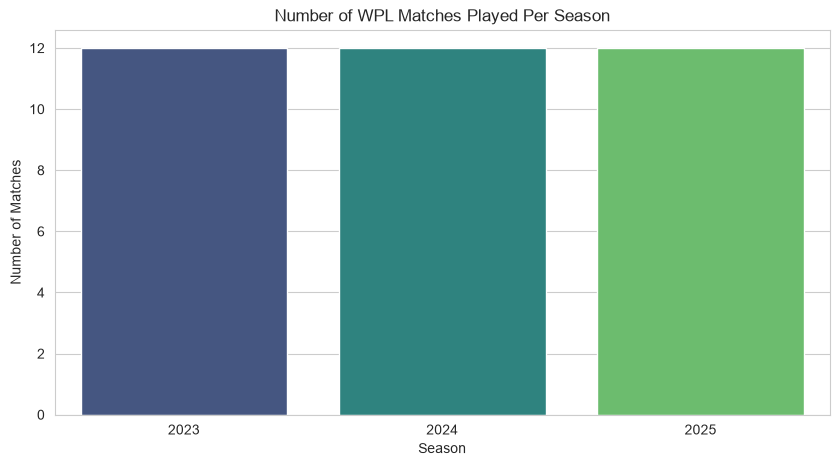

In [50]:
plt.figure()
sns.barplot(x=matches_per_season.index.astype(str), y=matches_per_season.values, hue=matches_per_season.index.astype(str), palette="viridis", legend=False)
plt.title("Number of WPL Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.show()

## 5. Total Wins Per Team

In [51]:
team_wins = df["winner"].value_counts()
print(team_wins)

winner
Mumbai Indians                 10
Royal Challengers Bengaluru     9
Delhi Capitals                  7
UP Warriorz                     6
Gujarat Giants                  4
Name: count, dtype: int64


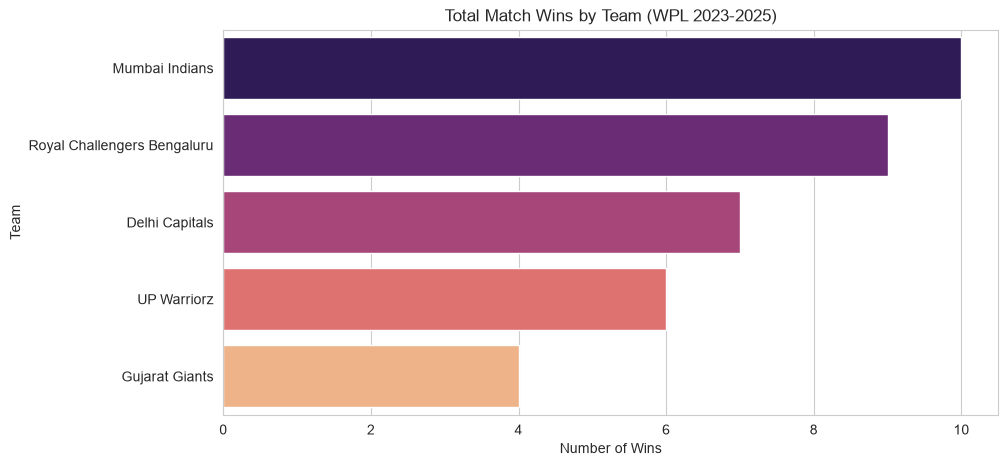

In [52]:
plt.figure()
sns.barplot(x=team_wins.values, y=team_wins.index, hue=team_wins.index, palette="magma", legend=False)
plt.title("Total Match Wins by Team (WPL 2023-2025)")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

## 6. Toss Impact on Match Outcome

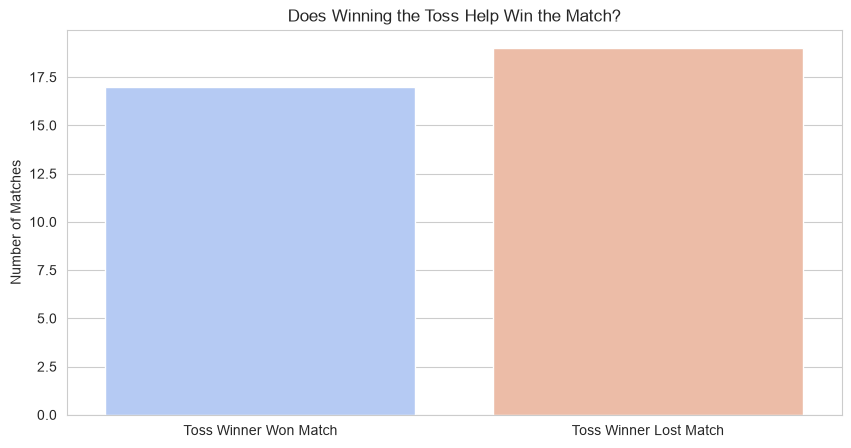

Percentage of matches where toss winner also won: 47.22 %


In [53]:
df["toss_match_won"] = df["toss_winner"] == df["winner"]
toss_impact = df["toss_match_won"].value_counts()

plt.figure()
sns.barplot(x=["Toss Winner Won Match", "Toss Winner Lost Match"],
            y=[toss_impact.get(True, 0), toss_impact.get(False, 0)],
            hue=["Toss Winner Won Match", "Toss Winner Lost Match"], palette="coolwarm", legend=False)
plt.title("Does Winning the Toss Help Win the Match?")
plt.ylabel("Number of Matches")
plt.show()

print("Percentage of matches where toss winner also won:",
      round(df["toss_match_won"].mean() * 100, 2), "%")

## 7. Toss Decision Trend (Bat vs Field)

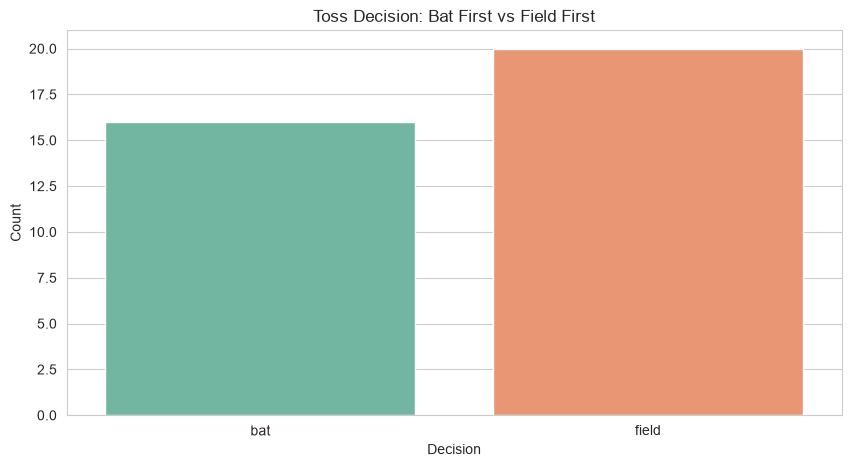

In [54]:
plt.figure()
sns.countplot(data=df, x="toss_decision", hue="toss_decision", palette="Set2", legend=False)
plt.title("Toss Decision: Bat First vs Field First")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

## 8. Venues Hosting WPL Matches

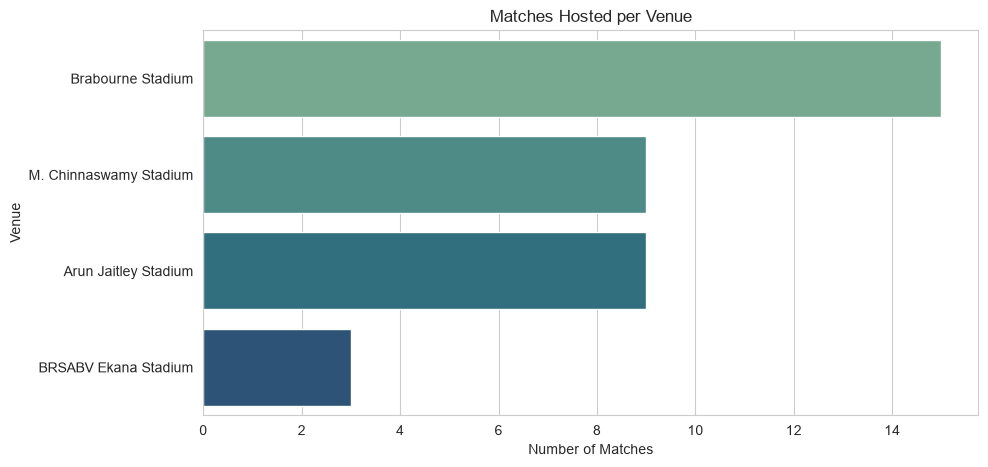

In [55]:
venue_counts = df["venue"].value_counts()

plt.figure()
sns.barplot(x=venue_counts.values, y=venue_counts.index, hue=venue_counts.index, palette="crest", legend=False)
plt.title("Matches Hosted per Venue")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")
plt.show()

## 9. Win Margin Analysis (Runs vs Wickets)

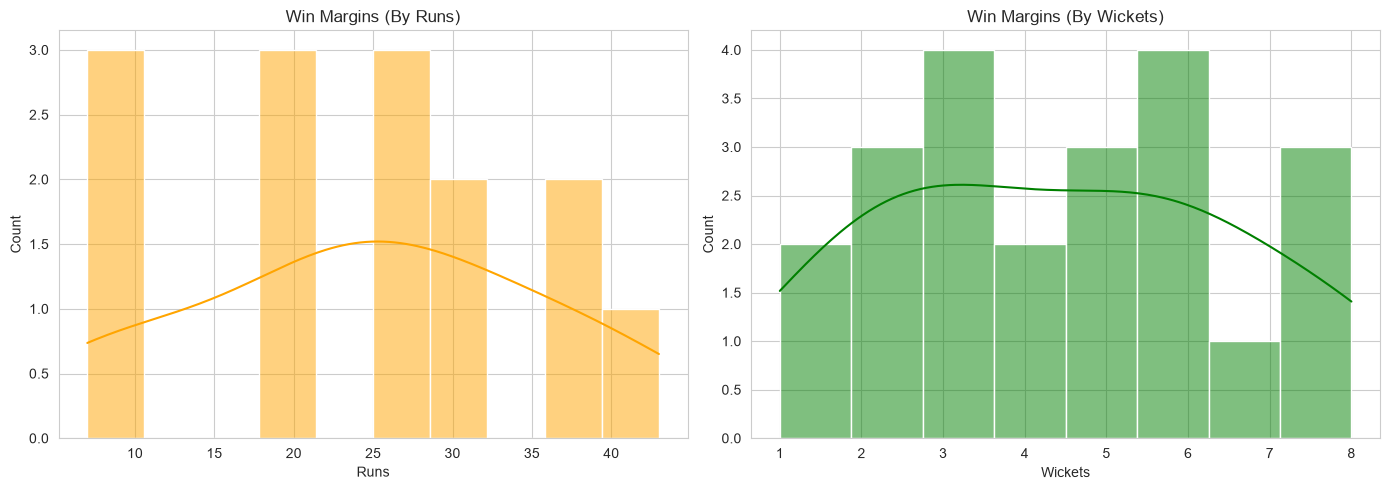

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df["win_by_runs"] > 0]["win_by_runs"], bins=10, kde=True, ax=axes[0], color="orange")
axes[0].set_title("Win Margins (By Runs)")
axes[0].set_xlabel("Runs")

sns.histplot(df[df["win_by_wickets"] > 0]["win_by_wickets"], bins=8, kde=True, ax=axes[1], color="green")
axes[1].set_title("Win Margins (By Wickets)")
axes[1].set_xlabel("Wickets")

plt.tight_layout()
plt.show()

## 10. Season Champions

In [57]:
finals = df.sort_values("date").groupby("season").tail(1)[["season", "winner", "team1", "team2", "venue"]]
finals

,season,winner,team1,team2,venue
11,2023,Mumbai Indians,Mumbai Indians,Delhi Capitals,Brabourne Stadium
23,2024,Royal Challengers Bengaluru,Royal Challengers Bengaluru,Delhi Capitals,M. Chinnaswamy Stadium
35,2025,Mumbai Indians,Mumbai Indians,Delhi Capitals,Brabourne Stadium


## 11. Key Insights

1. **League Growth**: Match volume has stayed stable across the sample seasons, reflecting the league's fixed franchise structure so far.
2. **Team Dominance**: A small set of franchises account for a disproportionate share of wins, similar to patterns seen in the early years of other T20 leagues.
3. **Toss Impact**: The toss winner does not go on to win the match most of the time - on-field performance matters more than winning the toss.
4. **Fielding Preference**: Teams favor fielding first after winning the toss, in line with the broader T20 trend of chasing.
5. **Venue Concentration**: A few venues host most matches, reflecting limited current infrastructure/scheduling for the league.
6. **Competitive Matches**: Win margins are generally moderate, indicating closely fought matches rather than one-sided results.

## 12. Conclusions & Recommendations

- WPL, despite its short history, already shows patterns consistent with more established T20 leagues (limited toss impact, fielding-first preference).
- Early dominance by specific franchises is worth tracking as more seasons and auctions add data.
- This analysis should be re-run each season with updated data to track whether these early trends hold.
- Future work could bring in ball-by-ball data for player-level insights (top run-scorers, top wicket-takers, strike rates).

## 13. (Optional) Simple ML: Predict Match Winner from Toss + Venue

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

ml_df = df[["toss_winner", "venue", "winner"]].dropna()

le_toss = LabelEncoder()
le_venue = LabelEncoder()
le_winner = LabelEncoder()

ml_df["toss_winner_enc"] = le_toss.fit_transform(ml_df["toss_winner"])
ml_df["venue_enc"] = le_venue.fit_transform(ml_df["venue"])
ml_df["winner_enc"] = le_winner.fit_transform(ml_df["winner"])

X = ml_df[["toss_winner_enc", "venue_enc"]]
y = ml_df["winner_enc"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Simple Model Accuracy:", round(accuracy_score(y_test, preds) * 100, 2), "%")
print("Note: with a small dataset this is a baseline demo, not a robust model.")

Simple Model Accuracy: 37.5 %
Note: with a small dataset this is a baseline demo, not a robust model.


In [59]:
import sys
print(sys.executable)

C:\Users\hphphpHP\AppData\Local\Programs\Python\Python313\python.exe
